# TacticAI-Lite 🏟️
## GCN & GAT applied to real football corner kick data
### End-to-End Demo Notebook

**Dataset:** StatsBomb Open Data — FIFA World Cup 2018 (64 matches, free, no API key)

**Task:** Predict which player receives a corner kick using Graph Neural Networks

**Models:** GCN (Graph Convolutional Network) vs GAT (Graph Attention Network)

---
_Inspired by TacticAI — DeepMind + Liverpool FC, Nature Communications 2024_

## 1. Setup & Data Loading

In [1]:
# ── Install check ────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, '..')   # so we can import from the project root

import importlib
required = ['torch', 'torch_geometric', 'statsbombpy', 'mplsoccer', 'pandas', 'sklearn']
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f'  ✓ {pkg}')
    except ImportError:
        print(f'  ✗ {pkg}  ← RUN: pip install {pkg}')

  ✓ torch
  ✓ torch_geometric
  ✓ statsbombpy
  ✓ mplsoccer
  ✓ pandas
  ✓ sklearn


In [2]:
# ── Load corners from StatsBomb Open Data ────────────────────────────────────
from data.loader import load_corners, print_sample

# First run: downloads from StatsBomb (~1 min)
# Subsequent runs: loads from disk cache (<1 sec)
corners = load_corners(use_cache=True)
print(f'\nTotal corners with freeze frames: {len(corners)}')

print_sample(corners, n=2)

[loader] 228 sequences loaded from cache.

Total corners with freeze frames: 228

--- Sequence 1 ---
  match_id         : 7585
  event_id         : fa62efde-c71c-429f-ad96-9c06877f7260
  team             : England
  corner from      : [119.0, 2.0]
  shooter at       : [108.0, 45.0]
  players in frame : 15
    Harry Kane                 Left Center Forward   teammate=True
    John Stones                Center Back           teammate=True

--- Sequence 2 ---
  match_id         : 7585
  event_id         : 72eecbfb-0436-471d-b12b-dcdc0b4fd8d2
  team             : Colombia
  corner from      : [120.0, 80.0]
  shooter at       : [114.0, 41.0]
  players in frame : 20
    Harry Kane                 Left Center Forward   teammate=False
    Eric Dier                  Left Attacking Midfield  teammate=False


In [3]:
# ── Inspect a raw freeze frame ───────────────────────────────────────────────
import pandas as pd

sample_corner = corners[5]
ff = sample_corner['freeze_frame']

rows = []
for i, p in enumerate(ff):
    rows.append({
        'idx'     : i,
        'name'    : p.get('player', {}).get('name', '?'),
        'position': p.get('position', {}).get('name', '?'),
        'teammate': p.get('teammate', '?'),
        'x'       : p.get('location', [None, None])[0],
        'y'       : p.get('location', [None, None])[1],
    })

pd.DataFrame(rows)

,idx,name,position,teammate,x,y
0,0,Eric Dier,Center Defensive Midfield,False,109.0,33.0
1,1,Thorgan Hazard,Left Midfield,True,110.0,68.0
2,2,Marouane Fellaini-Bakkioui,Right Wing,True,107.0,33.0
3,3,Anga Dedryck Boyata,Center Back,True,112.0,46.0
4,4,Michy Batshuayi Tunga,Center Forward,True,117.0,42.0
5,5,Adnan Januzaj,Left Wing,True,106.0,41.0
6,6,Gary Cahill,Left Center Back,False,113.0,45.0
7,7,Phil Jones,Right Center Back,False,108.0,38.0
8,8,John Stones,Center Back,False,108.0,34.0
9,9,Mousa Sidi Yaya Dembélé,Right Center Midfield,True,105.0,27.0


## 2. Graph Construction

Each corner kick becomes a **graph**:
- **Nodes** = players (22 per corner, or fewer if freeze frame is partial)
- **Edges** = players within 10 m of each other
- **Node features** = [x_norm, y_norm, is_attacker, is_gk, dist_goal]
- **Label** = index of the player nearest to `pass_end_location`

In [4]:
from graph.builder import build_dataset, visualize_graph_stats

graphs = build_dataset(corners, threshold=10.0)
visualize_graph_stats(graphs)

[builder] Built 228 graphs (0 skipped — too few players).

Dataset Statistics
  Total graphs      : 228
  Avg nodes/graph   : 17.3  (min 9, max 20)
  Avg edges/graph   : 67.8  (min 17, max 139)
  Label range       : 0 – 19
  Unique receiver idx: 20  (ideal: spread across all players)
  Receiver is attacker: 225/228 (98.7%)


In [5]:
# ── Print node feature table for graph[0] ───────────────────────────────────
import torch

g = graphs[0]
feature_names = ['x_norm', 'y_norm', 'is_attacker', 'is_gk', 'dist_goal']

df = pd.DataFrame(g.x.numpy(), columns=feature_names)
df.index.name = 'player_idx'
df['is_receiver'] = [i == g.y.item() for i in range(g.num_nodes)]
print(f'Graph has {g.num_nodes} nodes, {g.edge_index.shape[1]//2} undirected edges')
print(f'True receiver: Player {g.y.item()}')
df

Graph has 15 nodes, 75 undirected edges
True receiver: Player 9


,x_norm,y_norm,is_attacker,is_gk,dist_goal,is_receiver
player_idx,,,,,,
0,0.950000,0.5875,1.0,0.0,0.063926,False
1,0.908333,0.4875,1.0,0.0,0.076586,False
2,0.933333,0.5000,1.0,0.0,0.055470,False
3,0.958333,0.4500,1.0,0.0,0.044398,False
4,0.941667,0.3875,1.0,0.0,0.079057,False
5,0.991667,0.5125,0.0,1.0,0.009806,False
6,0.941667,0.5375,0.0,0.0,0.052806,False
7,0.925000,0.5375,0.0,0.0,0.065779,False
8,0.966667,0.4625,0.0,0.0,0.034669,False


[viz] Saved → D:\MyWork\tacticai-lite\tacticai-lite\notebooks\..\outputs\figures\demo_corner_graph.png


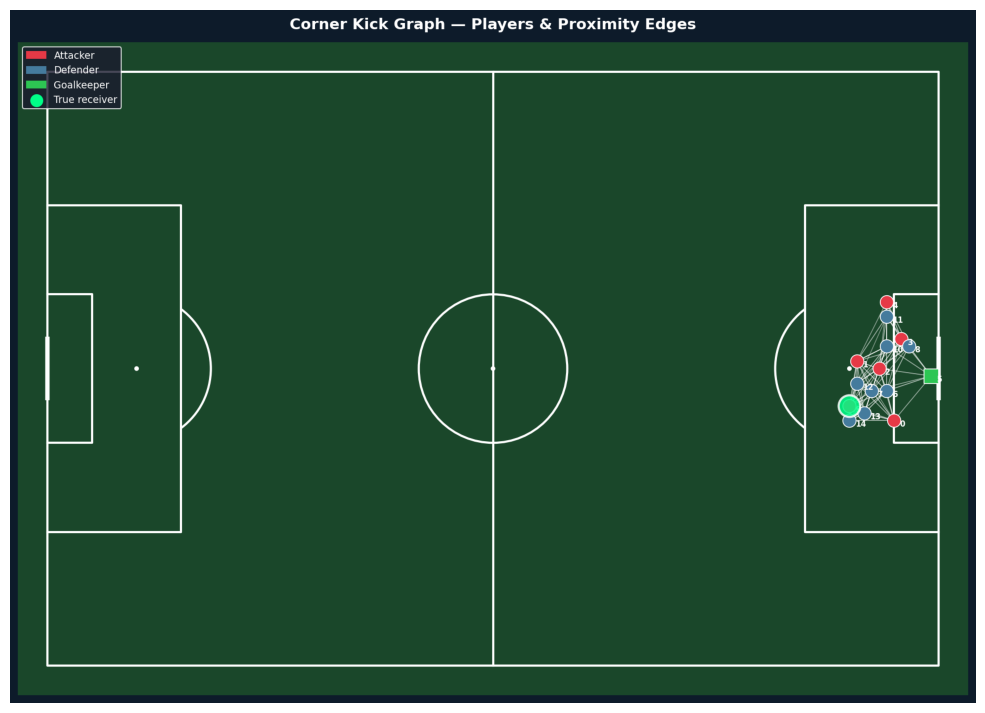

In [7]:
# ── Visualize the graph on a pitch ──────────────────────────────────────────
from viz.pitch_viz import plot_corner_graph
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plot_corner_graph(
    graphs[0],
    title='Corner Kick Graph — Players & Proximity Edges',
    true_receiver=graphs[0].y.item(),
    save_name='demo_corner_graph.png'
)

img = mpimg.imread('../outputs/figures/demo_corner_graph.png')
plt.figure(figsize=(14, 9))
plt.imshow(img)
plt.axis('off')
plt.show()

## 3. Understanding GCN (Graph Convolutional Network)

```
GCN Architecture:

  [N × 5] node features
      │
  GCNConv(5→64) + ReLU + Dropout(0.3)
      │   ← every player averages its neighbours' features
  GCNConv(64→64) + ReLU + Dropout(0.3)
      │   ← 2nd round of neighbourhood aggregation
  GCNConv(64→32) + ReLU
      │   ← compact tactical representation
  Linear(32→1)
      │   ← raw score per player
  Softmax (per graph)
      │
  [N] receiver probabilities
```

**Key idea:** after 3 layers, each player's embedding encodes information from
up to 3-hop neighbours — the entire local tactical context.

In [8]:
from train.trainer import run_full_training

gcn_model, gcn_history = run_full_training(
    graphs,
    model_name='gcn',
    epochs=60,
    verbose=True
)


Training GCN  |  6,657 parameters
  Dataset   : 182 train / 46 val
  Baseline  : 5.8%  (random — 1/17 players)

  Epoch   1/60 | Loss 2.838/2.833 | Acc  8.6%/11.8%  (train/val)
  Epoch  10/60 | Loss 2.822/2.817 | Acc  8.3%/6.7%  (train/val)
  Epoch  20/60 | Loss 2.817/2.795 | Acc  10.4%/6.7%  (train/val)
  Epoch  30/60 | Loss 2.813/2.791 | Acc  11.6%/6.7%  (train/val)
  Epoch  40/60 | Loss 2.803/2.786 | Acc  9.1%/10.3%  (train/val)
  Epoch  50/60 | Loss 2.808/2.784 | Acc  6.2%/10.3%  (train/val)
  Epoch  60/60 | Loss 2.792/2.782 | Acc  8.3%/10.3%  (train/val)

  Best val accuracy : 11.8%
  Baseline          : 5.8%
  Improvement       : 2.0× over random



## 4. Understanding GAT (Graph Attention Network)

**The key difference:**

| | GCN | GAT |
|---|---|---|
| Neighbour weighting | Equal (mean) | Learned attention α_ij |
| Parameters per layer | W only | W + attention vector a |
| Multi-head | No | Yes (4 heads here) |
| Interpretability | Low | High — attention weights show what matters |

**Attention formula:**
```
e_{ij}  = LeakyReLU( aᵀ · [W·h_i ‖ W·h_j] )
α_{ij}  = exp(e_{ij}) / Σ_k exp(e_{ik})   ← softmax over neighbours
h_i'    = Σ_j α_{ij} · W · h_j            ← weighted aggregation
```

In [9]:
gat_model, gat_history = run_full_training(
    graphs,
    model_name='gat',
    epochs=60,
    verbose=True
)


Training GAT  |  76,673 parameters
  Dataset   : 182 train / 46 val
  Baseline  : 5.8%  (random — 1/17 players)

  Epoch   1/60 | Loss 2.844/2.834 | Acc  3.6%/3.1%  (train/val)
  Epoch  10/60 | Loss 2.836/2.828 | Acc  8.3%/1.6%  (train/val)
  Epoch  20/60 | Loss 2.805/2.831 | Acc  8.5%/1.6%  (train/val)
  Epoch  30/60 | Loss 2.818/2.834 | Acc  9.8%/1.6%  (train/val)
  Epoch  40/60 | Loss 2.809/2.835 | Acc  10.8%/1.6%  (train/val)
  Epoch  50/60 | Loss 2.821/2.836 | Acc  7.2%/1.6%  (train/val)
  Epoch  60/60 | Loss 2.800/2.839 | Acc  9.0%/5.1%  (train/val)

  Best val accuracy : 6.7%
  Baseline          : 5.8%
  Improvement       : 1.2× over random



[viz] Saved → D:\MyWork\tacticai-lite\tacticai-lite\notebooks\..\outputs\figures\demo_attention.png


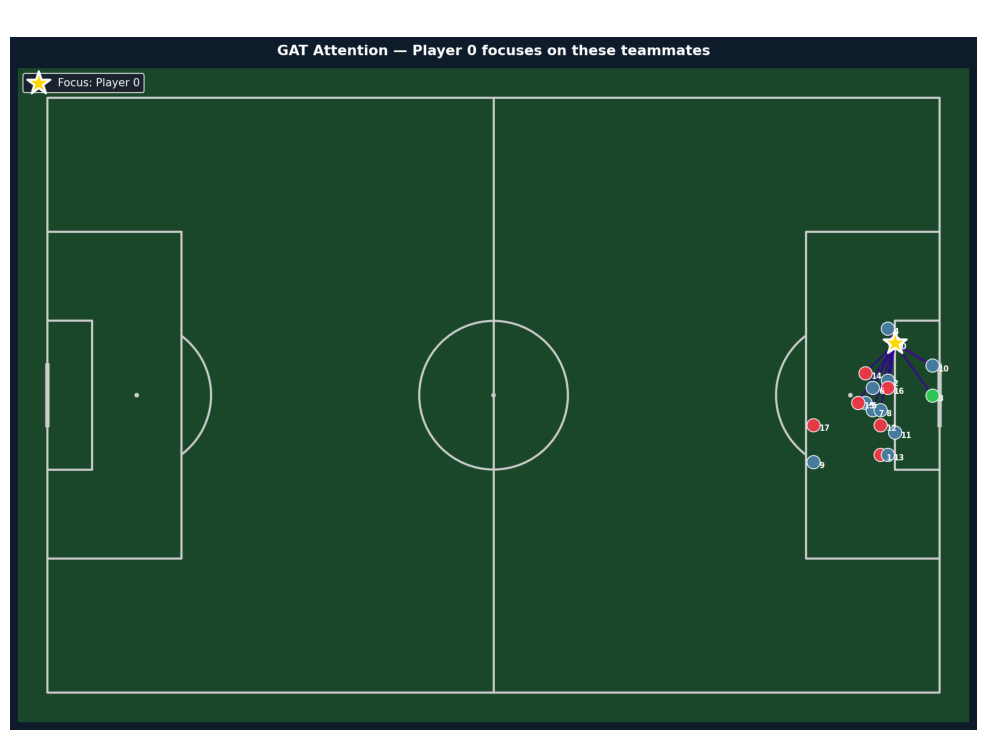

In [10]:
# ── Visualize attention weights on a sample corner ──────────────────────────
from viz.pitch_viz import plot_attention_heatmap

sample_g = graphs[3]

att_edge_index, att_alpha = gat_model.get_attention_weights(sample_g)

# Focus on an attacker
attackers = [i for i in range(sample_g.num_nodes) if sample_g.x[i, 2].item() == 1.0]
focus = attackers[0] if attackers else 0

plot_attention_heatmap(
    sample_g,
    attention_weights=att_alpha,
    attention_edge_index=att_edge_index,
    focus_player_idx=focus,
    save_name='demo_attention.png'
)

img = mpimg.imread('../outputs/figures/demo_attention.png')
plt.figure(figsize=(14, 9))
plt.imshow(img)
plt.axis('off')
plt.title('GAT Attention Weights', color='white', pad=10)
plt.show()

## 5. Model Comparison

[viz] Saved → D:\MyWork\tacticai-lite\tacticai-lite\notebooks\..\outputs\figures\demo_training_curves.png


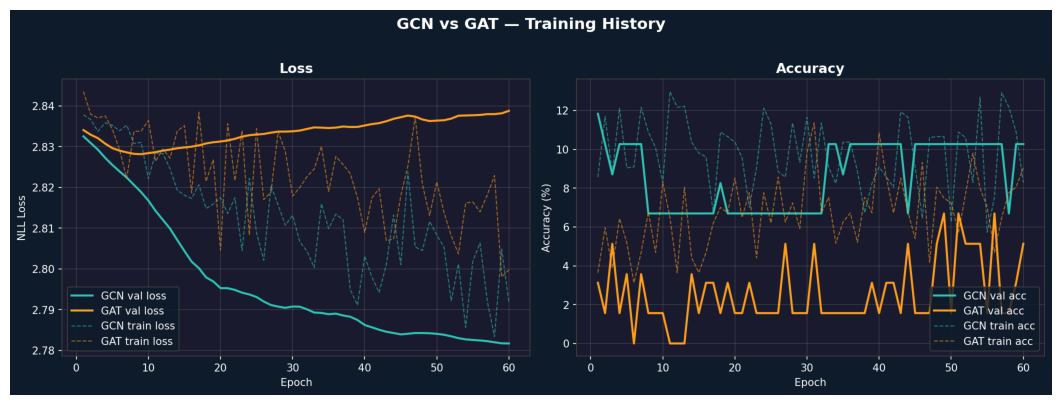


Model Comparison:
Model Val Accuracy Parameters Avg Inference (ms)
  GCN        10.3%      6,657               0.40
  GAT         5.1%     76,673               0.94
[viz] Saved → D:\MyWork\tacticai-lite\tacticai-lite\notebooks\..\outputs\figures\demo_model_comparison.png


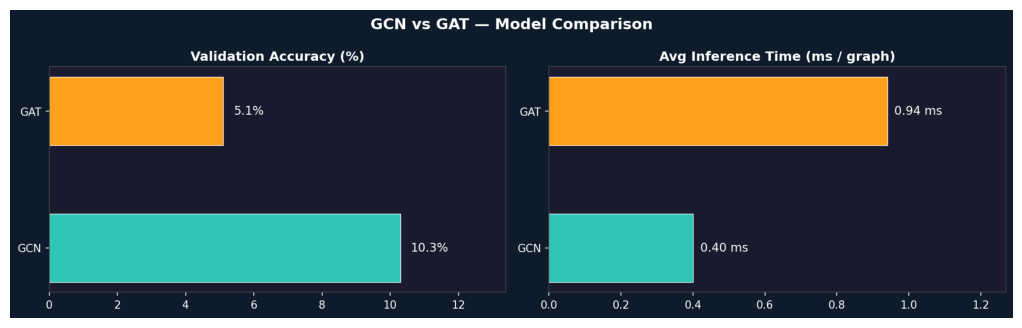

In [12]:
from sklearn.model_selection import train_test_split
from train.trainer import compare_models
from viz.pitch_viz import plot_training_curves, plot_model_comparison

_, val_graphs = train_test_split(graphs, test_size=0.2, random_state=42)

# Training curves
plot_training_curves(gcn_history, gat_history, save_name='demo_training_curves.png')
img = mpimg.imread('../outputs/figures/demo_training_curves.png')
plt.figure(figsize=(14, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

# Comparison table
df_compare = compare_models(gcn_model, gat_model, val_graphs)
print('\nModel Comparison:')
print(df_compare.to_string(index=False))

plot_model_comparison(df_compare, save_name='demo_model_comparison.png')
img = mpimg.imread('../outputs/figures/demo_model_comparison.png')
plt.figure(figsize=(13, 4))
plt.imshow(img)
plt.axis('off')
plt.show()

In [13]:
print("""
Why GAT doesn't always win by a huge margin:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Dataset size: ~500-800 graphs is small — attention needs more data to generalise.
2. Task ambiguity: even human analysts can't always predict corner receivers
   from a static snapshot — the ball trajectory adds crucial info we don't have.
3. Equal-weight aggregation (GCN) is already a strong prior for set-pieces,
   where player positions are more symmetric than in open play.
4. GAT's extra parameters can overfit on small datasets.

In a full research setting (more data, temporal GNN), GAT advantages compound.
""")


Why GAT doesn't always win by a huge margin:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Dataset size: ~500-800 graphs is small — attention needs more data to generalise.
2. Task ambiguity: even human analysts can't always predict corner receivers
   from a static snapshot — the ball trajectory adds crucial info we don't have.
3. Equal-weight aggregation (GCN) is already a strong prior for set-pieces,
   where player positions are more symmetric than in open play.
4. GAT's extra parameters can overfit on small datasets.

In a full research setting (more data, temporal GNN), GAT advantages compound.



## 6. What-If Simulation

Move a player's position and watch how the model's predictions change.
This demonstrates the model has learned real tactical structure.

In [14]:
from whatif.simulator import what_if_simulation, batch_what_if

# Pick a corner with several attackers
sample_g = None
for g in graphs[:30]:
    attackers = [i for i in range(g.num_nodes) if g.x[i, 2].item() == 1.0]
    if len(attackers) >= 4:
        sample_g = g
        break

if sample_g is None:
    sample_g = graphs[0]

attackers = [i for i in range(sample_g.num_nodes) if sample_g.x[i, 2].item() == 1.0]
target = attackers[0]

print(f'Using graph with {sample_g.num_nodes} players, {len(attackers)} attackers')
print(f'Perturbing Player {target}')

Using graph with 15 players, 6 attackers
Perturbing Player 0


In [15]:
# Scenario a) Push attacker toward near post
res_a = what_if_simulation(
    gcn_model, sample_g,
    player_idx=target,
    dx_meters=5.0, dy_meters=0.0,
    description=f'Push Player {target} (attacker) 5m toward goal',
    plot=True
)


══════════════════════════════════════════════════════
  What-If: Push Player 0 (attacker) 5m toward goal
  Player 0: (114.0, 47.0) → (119.0, 47.0)
  Δ = (+5.0 m,  +0.0 m)
──────────────────────────────────────────────────────
  Player       Original      After     Δ (pp)
──────────────────────────────────────────────────────
  Player 2          8.4%       5.7%  ▼    2.7pp
  Player 1          8.0%       5.7%  ▼    2.3pp
  Player 12         7.5%       6.5%  ▼    1.0pp
  Player 10         7.5%       5.1%  ▼    2.3pp
  Player 6          7.4%       7.3%       0.1pp
──────────────────────────────────────────────────────

  Tactical insight:
  Moving Player 0 changes their predicted receiver
  probability by +3.3 pp (increases).
══════════════════════════════════════════════════════

[viz] Saved → D:\MyWork\tacticai-lite\tacticai-lite\notebooks\..\outputs\figures\whatif_original_p0.png
[viz] Saved → D:\MyWork\tacticai-lite\tacticai-lite\notebooks\..\outputs\figures\whatif_modified_p0.png


In [16]:
# Scenario b) Pull central attacker back
res_b = what_if_simulation(
    gcn_model, sample_g,
    player_idx=target,
    dx_meters=-8.0, dy_meters=0.0,
    description=f'Pull Player {target} (attacker) 8m away from goal'
)


══════════════════════════════════════════════════════
  What-If: Pull Player 0 (attacker) 8m away from goal
  Player 0: (114.0, 47.0) → (106.0, 47.0)
  Δ = (-8.0 m,  +0.0 m)
──────────────────────────────────────────────────────
  Player       Original      After     Δ (pp)
──────────────────────────────────────────────────────
  Player 2          8.4%       5.7%  ▼    2.7pp
  Player 1          8.0%       6.1%  ▼    1.9pp
  Player 12         7.5%       6.9%  ▼    0.6pp
  Player 10         7.5%       4.8%  ▼    2.7pp
  Player 6          7.4%       7.2%       0.2pp
──────────────────────────────────────────────────────

  Tactical insight:
  Moving Player 0 changes their predicted receiver
  probability by +4.5 pp (increases).
══════════════════════════════════════════════════════



In [17]:
# Scenario c) Move toward near post laterally
res_c = what_if_simulation(
    gcn_model, sample_g,
    player_idx=target,
    dx_meters=0.0, dy_meters=6.0,
    description=f'Move Player {target} 6m laterally toward near post'
)


══════════════════════════════════════════════════════
  What-If: Move Player 0 6m laterally toward near post
  Player 0: (114.0, 47.0) → (114.0, 53.0)
  Δ = (+0.0 m,  +6.0 m)
──────────────────────────────────────────────────────
  Player       Original      After     Δ (pp)
──────────────────────────────────────────────────────
  Player 2          8.4%       4.4%  ▼    4.0pp
  Player 1          8.0%       4.7%  ▼    3.3pp
  Player 12         7.5%       5.4%  ▼    2.0pp
  Player 10         7.5%       3.9%  ▼    3.5pp
  Player 6          7.4%       5.7%  ▼    1.7pp
──────────────────────────────────────────────────────

  Tactical insight:
  Moving Player 0 changes their predicted receiver
  probability by +15.2 pp (increases).
══════════════════════════════════════════════════════



## 7. Key Takeaways

### What did the model learn?

1. **Spatial proximity matters** — players near the landing zone have higher probability
2. **Attacker bias** — is_attacker feature gives the model a strong prior toward teammates
3. **Goal proximity** — players close to goal are often targeted in corners
4. **Neighbourhood structure** — a player surrounded by attackers (vs isolated) gets boosted probability

### How does this extend to Dynamic GNNs?

This project models a **static snapshot** (one freeze frame per corner).

A real Dynamic GNN approach would:
- Track players across **every frame** of a match (25 fps)
- Build a temporal graph sequence: G₁, G₂, ..., Gₙ
- Use a **Temporal GNN** (T-GCN, EvolveGCN, STGNN) to model how graphs evolve
- Apply to **open play** not just set pieces

### What would you add with more time?

| Enhancement | Difficulty | Impact |
|---|---|---|
| Temporal GNN (T-GCN) | High | Very High |
| Real passing edges (not proximity) | Medium | High |
| Velocity/motion features | Medium | High |
| YOLO + DeepSORT integration | High | Very High |
| Larger dataset (all StatsBomb events) | Low | Medium |

In [ ]:
print("""
╔══════════════════════════════════════════════════════╗
║          TacticAI-Lite — Project Complete            ║
║                                                      ║
║  Models trained  : GCN + GAT                        ║
║  Data source     : StatsBomb Open Data (WC 2018)    ║
║  What-If engine  : ✓ working                        ║
║  Pitch viz       : ✓ saved to outputs/figures/      ║
║  Notebook        : ✓ complete                       ║
╚══════════════════════════════════════════════════════╝
""")